# Projeto de Ciência de Dados: Titanic

Caio Santos de Almeida, caiosantal.cd@gmail.com<br>
São Paulo - SP <br>
https://www.linkedin.com/in/caiosantal <br>

<hr>

Vamos considerar o problema de classificação dos passageiros do Titanic disponível no portal Kaggle:
> https://www.kaggle.com/c/titanic

Ou seja, o objetivo é construir um projeto para classificar os dados e posterior submissão, de modo a verificar o quão preciso são nossos resultados comparados com soluções de outros usuários. Vamos mostrar todas as fases do projeto e os resultados, mas lembramos que essa é uma possível solução. Um cientista de dados deve aprender com os erros e sempre tentar melhorar um projeto, aprendendo em todas as fases de seu desenvolvimento.

## 1 - Formulação do problema e leitura dos dados

Vamos considerar a base de dados de passageiros que viajaram no Titanic.

Os atributos contidos nos dados:<br>
1 - PassengerId: Número de identificação do passageiro;<br>
2 - Survived: Indica se o passageiro sobreviveu ao desastre. É atribuído o valor de 0 para aqueles que não sobreviveram, e 1 para quem sobreviveu;<br>
3 - Pclass: Classe na qual o passageiro viajou. É informado 1 para primeira classe; 2 para segunda; e 3 para terceira;<br>
4 - Name: Nome do passageiro;<br>
5 - Sex: Sexo do passageiro;<br>
6 - Age: Idade do passageiro em anos;<br>
7 - SibSp: Quantidade de irmãos e cônjuges a bordo;<br>
8 - Parch: Quantidade de pais e filhos a bordo;<br>
9 - Ticket: Número da passagem;<br>
10 - Fare: Preço da passagem;<br>
11 - Cabin: Número da cabine do passageiro;<br>
12 - Embarked: Indica o porto no qual o passageiro embarcou. Há apenas três valores possíveis: Cherbourg, Queenstown e Southampton, indicados pelas letras “C”, “Q” e “S”, respectivamente.

### **Nosso objetivo é classificar os passageiros como sobreviventes (ou não) de acordo com o conjunto de atributos.**

Fazendo a leitura dos dados:

In [81]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
random.seed(42) # definindo a seed
np.random.seed(10)

drive.mount('/content/drive/')
train = pd.read_csv('/content/drive/My Drive/dados//titanic/train.csv', header=(0))
test = pd.read_csv('/content/drive/My Drive/dados//titanic/test.csv', header=(0))

print("Número de linhas e colunas no conjunto de treinamento:", train.shape)
print("Número de linhas e colunas no conjunto de teste:", test.shape)
attributes = list(train.columns)
train.head(10) # Pega apenas os 10 primeiros resultados

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas no conjunto de treinamento: (891, 12)
Número de linhas e colunas no conjunto de teste: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Notem que temos um conjunto de treinamento e um conjunto de teste, que representa a aplicação de nosso modelo desenvolvido. É importante notar que, na prática, não vamos conhecer os resultados de problemas de classificação ou regressão, isto é, a saída $y$. No entanto, em nosso exemplo vamos poder submeter as soluções (a classificação do conjunto de teste) e verificar o quão boa é a nossa metodologia, comparando ainda com outras soluções apresentadas no site Kaggle. Em casos reais, as predições também poderão ser comparadas com resultados de casos desconhecidos ou predições futuras, como no caso de diagnóstico de doenças ou predição de preços no mercado de ações.

Assim, os dados no conjunto de teste não contém as classes, que devemos inferir.

In [44]:
print('Conjunto de teste')
test.head(10)

Conjunto de teste


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


Após a leitura dos dados e formualação dos problemas, podemos passar à fase de pré-processamento.

## 2 - Limpeza e normalização dos dados

Vemos que alguns atributos são irrelavantes, como PassengerId, Name, Ticket e Cabin. Vamos retirar esses atributos dos conjuntos de teste e treinamento. No entanto, usaremos o atributo PassengerId quando formos submeter nossa solução no Kaggle. Portanto, temos que guardar essa informação.

In [45]:
treino = train.drop(columns=['PassengerId','Name', 'Ticket', 'Cabin'])
treino.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


In [46]:
PassengerId_test = test['PassengerId']
teste = test.drop(columns=['PassengerId','Name', 'Ticket', 'Cabin'])
teste.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
5,3,male,14.0,0,0,9.2250,S
6,3,female,30.0,0,0,7.6292,Q
7,2,male,26.0,1,1,29.0000,S
8,3,female,18.0,0,0,7.2292,C
9,3,male,21.0,2,0,24.1500,S


O conjunto de dados pode apresentar valores nulos (*not a number: nan*). A sua identificação pode ser feita usando-se métodos da biblioteca Pandas.

Vamos verificar quantos valores nulos temos em nossos dados.

In [47]:
treino.isnull().sum().sort_values(ascending=False)

,0
Age,177
Embarked,2
Pclass,0
Survived,0
Sex,0
SibSp,0
Parch,0
Fare,0


In [48]:
teste.isnull().sum().sort_values(ascending=False)

,0
Age,86
Fare,1
Pclass,0
Sex,0
SibSp,0
Parch,0
Embarked,0


Se removermos a linhas com esses valores, vamos perder uma grande quantidade de dados. Para não descartamos as observações que contêm nan, vamos atribuir valores médios ou a moda às entradas nulas nos dados numéricos e a moda nos atributos nominais. Essa é a estratégia mais simples, mas outra mais sofisticadas, que podem considerar modelos de regressão para realizar a predição, podem ser consideradas.

In [49]:
treino['Age'] = treino['Age'].fillna(treino['Age'].mean())
treino['Embarked'] = treino['Embarked'].fillna(treino['Embarked'].mode()[0]) # preenche os valores nulos na coluna embarque pela moda do indice 0 pois pode ter empate (contagem igual em 2 valores)
treino['Fare'] = treino['Fare'].fillna(treino['Fare'].mean())

teste['Age'] = teste['Age'].fillna(teste['Age'].mean())
teste['Embarked'] = teste['Embarked'].fillna(teste['Embarked'].mode()[0])
teste['Fare'] = teste['Fare'].fillna(teste['Fare'].mean())

Vamos verificar novamente se os dados ainda contém valores nulos.

In [50]:
treino.isnull().sum().sort_values(ascending=False).head(10)

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [51]:
teste.isnull().sum().sort_values(ascending=False).head(10)

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Os atributos nominais podem ser transformados para numéricos usando one-hot-enconding.

In [52]:
treino_original = treino
treino = pd.get_dummies(treino, drop_first=True, dtype=int)
treino.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0
6,0,1,54.000000,0,0,51.8625,1,0,1
7,0,3,2.000000,3,1,21.0750,1,0,1
8,1,3,27.000000,0,2,11.1333,0,0,1
9,1,2,14.000000,1,0,30.0708,0,0,0


In [53]:
teste = pd.get_dummies(teste, drop_first=True, dtype=int)
teste.head(10)

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,1,1,0
1,3,47.0,1,0,7.0000,0,0,1
2,2,62.0,0,0,9.6875,1,1,0
3,3,27.0,0,0,8.6625,1,0,1
4,3,22.0,1,1,12.2875,0,0,1
5,3,14.0,0,0,9.2250,1,0,1
6,3,30.0,0,0,7.6292,0,1,0
7,2,26.0,1,1,29.0000,1,0,1
8,3,18.0,0,0,7.2292,0,0,0
9,3,21.0,2,0,24.1500,1,0,1


Para facilitar o processamento, vamos converter os dados para o formato numpy para podemos realizar a classificação.

In [54]:
data_train = treino.to_numpy()
nrow,ncol = data_train.shape
y_train = data_train[:,0] # Definindo coluna 0 como variavel y do modelo
y_train = y_train.astype(int) #Converte a variavel y para int caso esteja decimal
X_train = data_train[:,1:ncol] #Define a coluna 1 até a ultima coluna como a variavel X

Para o conjunto de teste:

In [55]:
data_test = teste.to_numpy()
X_test = data_test #Como no conjunto de teste não tem a variavel resposta (variavel dependente) define todas colunas como variaveis explicativas (variavel independente)

Vamos verificar se as classes estão balanceadas.

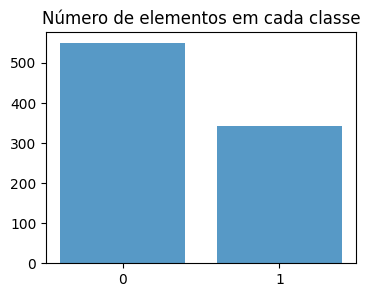

In [56]:
classes = y_train
cl = np.unique(classes) # Identifica quais são os valores possiveis, nesse caso 0 e 1
ncl = np.zeros(len(cl)) # Cria um array zerado do mesmo tamanho da quantidade de classes, esses vão ser o n° de contagem de 0s e 1s.
for i in np.arange(0, len(cl)):
    a = classes == cl[i] # Cria um filtro booleano (True onde for a classe atual e False onde não for).
    ncl[i] = len(classes[a]) # Conta quantas vezes aquela classe apareceu e salva o número no array ncl

numbers = np.arange(0, len(cl))
plt.figure(figsize=(4, 3))
plt.bar(numbers, ncl,  alpha=.75)
plt.xticks(numbers, cl)
plt.title('Número de elementos em cada classe')
plt.show(True)

Ou seja, há mais sobreviventes do que não-sobrevivente. Essa informação será importante na validação cruzada.

Vamos normalizar os dados:

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print('Dados transformados:')
print('Media: ', np.mean(X_train, axis = 0))
print('Desvio Padrao:', np.std(X_train, axis = 0))

print('Dados transformados:')
print('Media: ', np.mean(X_test, axis = 0))
print('Desvio Padrao:', np.std(X_test, axis = 0))

Dados transformados:
Media:  [-8.77213254e-17  2.23290646e-16  4.38606627e-17  5.38289951e-17
  3.98733297e-18 -1.15632656e-16  0.00000000e+00 -8.37339924e-17]
Desvio Padrao: [1. 1. 1. 1. 1. 1. 1. 1.]
Dados transformados:
Media:  [-0.05156969  0.04413122 -0.06863058  0.01334498  0.06892064 -0.02349348
  0.08409087 -0.1771445 ]
Desvio Padrao: [1.00625661 0.97111866 0.81269066 1.21679298 1.12298531 1.00695788
 1.11376674 1.07106262]


## 3 - Análise descritiva dos dados

Podemos analisar as variáveis individualmente ou sua relação, de modo a entender melhor os dados.

Inicialmente, vamos analisar a correlação entre os atributos.

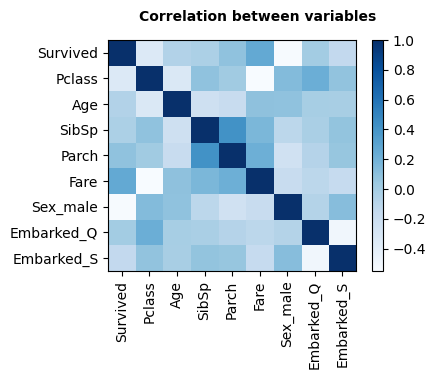

In [58]:
corr = treino.corr()
#Plot Correlation Matrix using Matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns);
plt.suptitle('Correlation between variables', fontsize=10, fontweight='bold')
plt.grid(False)
plt.show()

Observamos que os atributos não são fortemente correlacionados. Além disso, vemos que as mulheres sobreviveram mais do que os homens.

Para confirmar esse resultado, vamos analisar os dados de arcordo com o gênero. Observamos que a taxa de sobrevivência dos homens foi em torno de 25%, enquanto que a das mulheres, de 75%. Portanto, saber se o passageiro era homem ou mulher é uma informaçãom importante a ser levada em conta na classificação.

<Figure size 500x300 with 0 Axes>

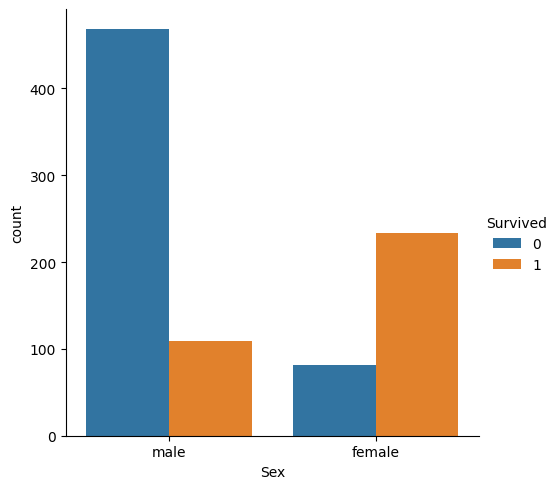

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.catplot(x ="Sex", hue ="Survived", kind ="count", data = treino_original)

Vamos analisar a relação entre a classe do passageiro e se o passageiro sobreviveu. Conforme observamos a seguir, grande parte das mortes ocorreram entre os passageiros da terceira classe. Portanto, essa informação também é importante para classificarmos os passageiros em sobreviventes.

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


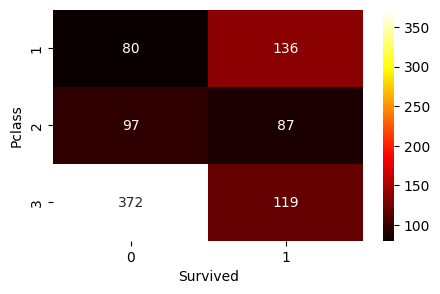

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

group = treino_original.groupby(['Pclass', 'Survived'])
pclass_survived = group.size().unstack()
plt.figure(figsize=(5, 3))
sns.heatmap(pclass_survived, annot = True, fmt ="d", cmap = 'hot')
print(pclass_survived)

De acordo com a idade, vemos que boa parte das crianças sobreviveram. Além disso, as mulheres com mais idade e os homens mais jovens apresentaram uma chance maior de sobrevier.

<Axes: xlabel='Sex', ylabel='Age'>

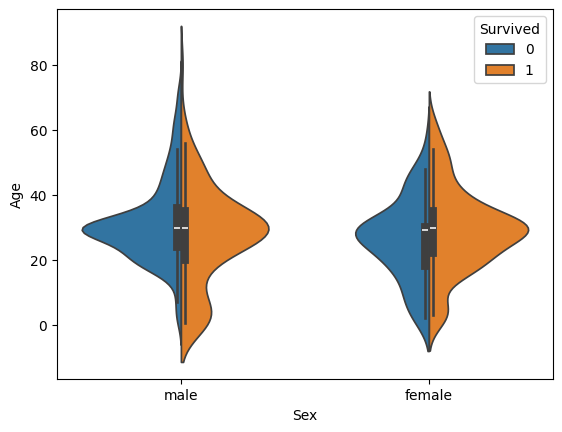

In [62]:
sns.violinplot(x ="Sex", y ="Age", hue ="Survived",
data = treino_original, split = True)

De acordo com o preço do bilhete, vemos que quanto mais caro, maior é a chance de sobrevivência, o que reforça que classe de embarque é uma variável importante.

<Axes: xlabel='Fare_Range', ylabel='Survived'>

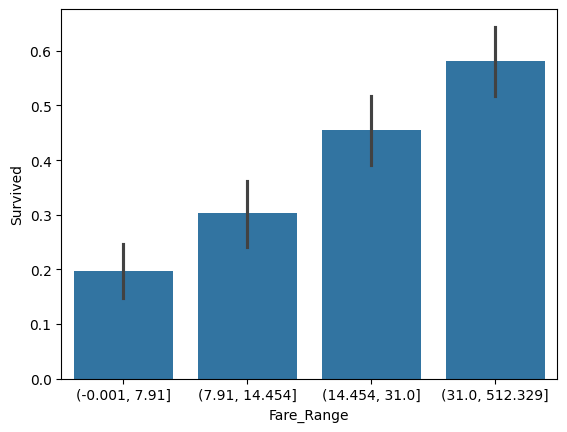

In [64]:
# Divide Fare into 4 bins
treino_original['Fare_Range'] = pd.qcut(treino_original['Fare'], 4)

# Barplot - Shows approximate values based on the height of bars.
sns.barplot(x ='Fare_Range', y ='Survived', data = treino_original)

De acordo com o porto de embarque, notamos que a maioria dos sobreviventes são do porto de Southampton (S). Além disso, em Queenstown (Q) embaracaram a maioria dos passageiros da terceira classe.

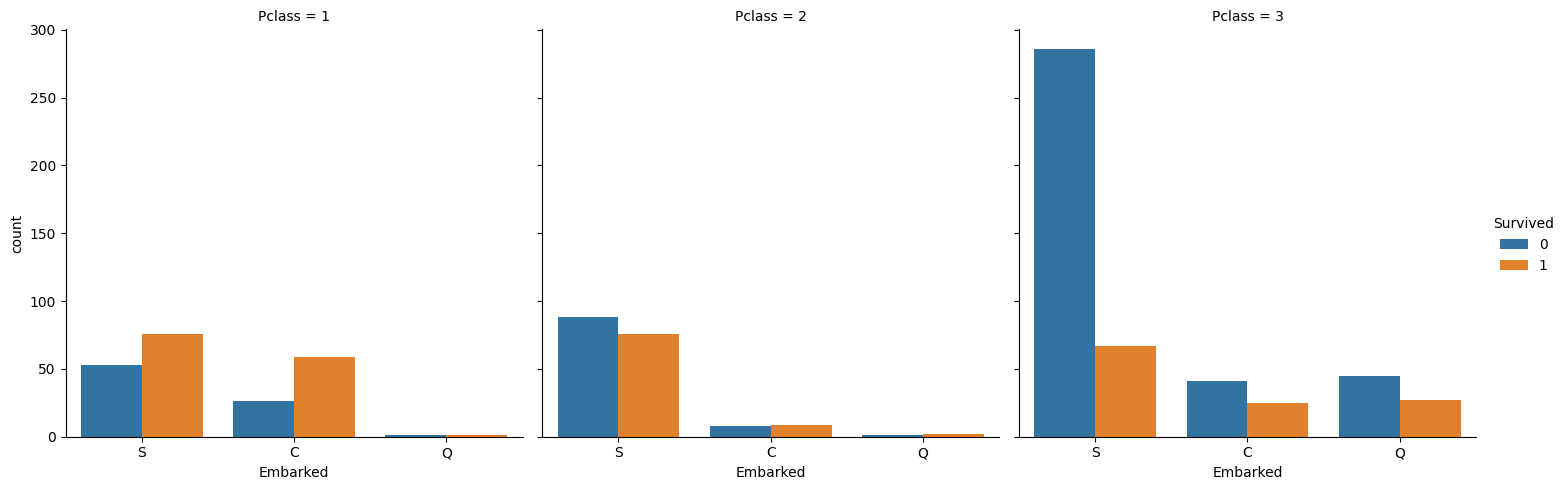

In [65]:
# Countplot
sns.catplot(x ='Embarked', hue ='Survived',
kind ='count', col ='Pclass', data = treino_original)

Portanto, vemos que vários atributos são importantes para separar as classes.

## 5 - Classificação

Vamos realizar a classificação usando o algoritmo Naive Bayes.

In [77]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import os
os.makedirs('/content/drive/My Drive/dados/out', exist_ok=True)
# Treina o modelo
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred = gnb.predict(X_test)

# acurácia no conjunto de treino
y_pred_train = gnb.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {accuracy_train}")

# Para submeter ao Kaggle, você precisa criar um arquivo CSV com o PassengerId e a predição:
submission = pd.DataFrame({'PassengerId': PassengerId_test, 'Survived': y_pred})
submission.to_csv('submission.csv', index=False)
submission.to_csv('/content/drive/My Drive/dados/out/Titanic-naive-bayes.csv', index = False)

Acurácia no conjunto de treino: 0.7890011223344556


Vamos usar também a regressão logística.

In [78]:
from sklearn.linear_model import LogisticRegression

# Treina o modelo de Regressão Logística
logreg = LogisticRegression(max_iter=1000)  # Aumentar max_iter se necessário
logreg.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred_logreg = logreg.predict(X_test)

# Acurácia no conjunto de treino
y_pred_train_logreg = logreg.predict(X_train)
accuracy_train_logreg = accuracy_score(y_train, y_pred_train_logreg)
print(f"Acurácia da Regressão Logística no conjunto de treino: {accuracy_train_logreg}")

# Criar arquivo de submissão para o Kaggle
submission_logreg = pd.DataFrame({'PassengerId': PassengerId_test, 'Survived': y_pred_logreg})
submission_logreg.to_csv('/content/drive/My Drive/dados/out/Titanic-logistic-regression.csv',
                          index=False)

Acurácia da Regressão Logística no conjunto de treino: 0.8002244668911336


Usando o método knn:

In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
k_range = list(range(1, 51))
param_grid = [{'n_neighbors': k_range, 'metric': ['euclidean', 'minkowski','chebyshev']}]

# defining parameter range
model = GridSearchCV(estimator = knn, param_grid = param_grid, cv=10, return_train_score=False,verbose=1)

# fitting the model for grid search
model.fit(X_train, y_train)
print(model.best_params_)
model.score(X_train, y_train)

Fitting 10 folds for each of 150 candidates, totalling 1500 fits
{'metric': 'euclidean', 'n_neighbors': 16}


0.8361391694725028

Após encontrar o melhor valor de $k$, podemos fazer a classificação usando o método dos k-vizinhos nos dados desconhecidos. Os resultados serão gravados em um arquivo para submetermos ao Kaggle.

In [80]:
y_pred = model.predict(X_test)
# escrever no arquivo
y_pred = np.array(y_pred, dtype = int)
prediction = pd.DataFrame()
prediction['PassengerId'] = PassengerId_test
prediction['Survived'] = y_pred
print("Acurácia no treinamento: ", model.score(X_train, y_train))
prediction.to_csv('/content/drive/My Drive/dados/out/Titanic-knn.csv', index = False)

Acurácia no treinamento:  0.8361391694725028


Enviando nossa solução para o Kaggle, obtemos: **Your submission scored 0.76794**